#### This notebook is learning process to test an E2E ML pipleline, from production to deployment, and will be using tools like, conda, git, dvc, mlflow, dagshub and docker

In [57]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import joblib
import subprocess
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,ConfusionMatrixDisplay

import mlflow
import mlflow.sklearn ## note: for pytorch just use mlflow.pytorch

In [5]:
# Set Dagshub credentials as environment variables
## MLflow uses these to authenticate when logging experiments to DagsHub's MLflow server


os.environ['MLFLOW_TRACKING_USERNAME'] = 'dbhagria-2004'
os.environ['MLFLOW_TRACKING_PASSWORD'] = '270cba642f134f3ff45ca191240d7e3976d2eaa4'

mlflow.set_tracking_uri('https://dagshub.com/dbhagria-2004/ML-PIPELINE-TEST.mlflow')

mlflow.set_experiment('digit-classifier')

2026/05/12 15:30:51 INFO mlflow.tracking.fluent: Experiment with name 'digit-classifier' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/f69ac79c40f94ac4919e0c5659447e25', creation_time=1778614251666, experiment_id='0', last_update_time=1778614251666, lifecycle_stage='active', name='digit-classifier', tags={}, trace_location=None, workspace='default'>

In [22]:
digits = load_digits()
data, target = digits.data, digits.target

df = pd.DataFrame(data, columns=[f'pixel_{i}' for i in range(64)])
df['target'] = target

In [23]:
df.head()

,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


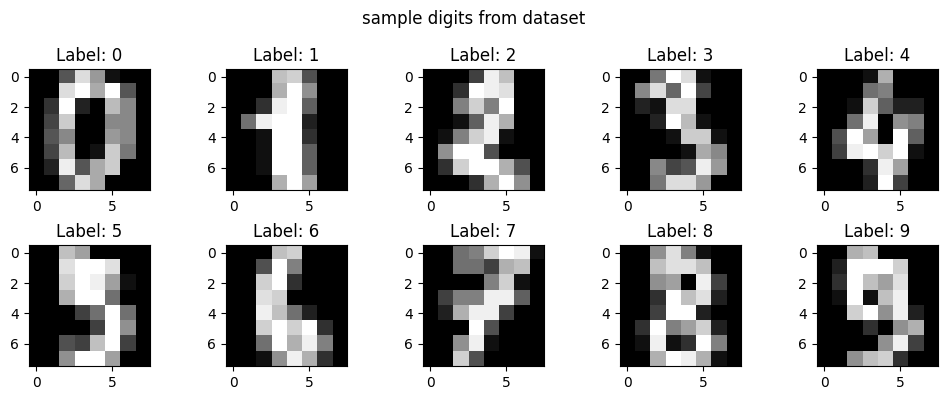

In [26]:
fig, axes = plt.subplots(2, 5, figsize=(10,4))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {target[i]}')

plt.suptitle("sample digits from dataset")
plt.tight_layout()
plt.show()


In [27]:
## saving them to csv's

df.to_csv('data/raw/digits.csv', index=False)
print(f"Raw data saved to data/raw/digits.csv ({len(df)} rows)")


Raw data saved to data/raw/digits.csv (1797 rows)


In [28]:
# Separate features (pixel values) from labels (digits 0-9)
X = df.drop('target', axis=1)  # everything except the target column
y = df['target']

# Split into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalize pixel values to mean=0, std=1

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)  # fit on train, transform train
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)          # only transform test (no fitting!)

print(f"Training set: {X_train_scaled.shape[0]} samples")
print(f"Test set:     {X_test_scaled.shape[0]} samples")


Training set: 1437 samples
Test set:     360 samples


In [30]:
X_train_scaled.to_csv('data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('data/processed/X_test.csv', index=False)
y_train.to_csv('data/processed/y_train.csv', index=False)
y_test.to_csv('data/processed/y_test.csv', index=False)

print("Processed data saved to data/processed/")

Processed data saved to data/processed/


#### Below is the training loop using mlflow logging

## First Experiment

In [ ]:
n_estimators = 100
max_depth = 10
random_state = 42

git_hash = subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode().strip()
with mlflow.start_run(run_name="Random_Forest_V1"):

  mlflow.log_param("model_type", "RandomForest")
  mlflow.log_param("n_estimator", n_estimators)
  mlflow.log_param("max_depth", max_depth)
  mlflow.log_param("random_state", random_state)
  mlflow.log_param("git_commit", git_hash)
  mlflow.log_param("data_version", git_hash[:8])

  
  model = RandomForestClassifier(
    n_estimators= n_estimators,
    max_depth= max_depth, 
    random_state=random_state
  )

  model.fit(X_train_scaled, y_train)

  y_pred = model.predict(X_test_scaled)

  accuracy = accuracy_score(y_test, y_pred)
  report = classification_report(y_test, y_pred, output_dict=True)

  mlflow.log_metric("accuracy", accuracy)
  # mlflow.log_metric("report", report)
  mlflow.log_metric("f1_weighted", report['weighted avg']['f1-score'])
  mlflow.log_metric("precision_weighted", report['weighted avg']['precision'])
  mlflow.log_metric("recall_weighted", report['weighted avg']['recall'])

  ## log model (use sklearn because sklearn model)
  mlflow.sklearn.log_model(model, "random_forest_model")

  print(f"Accuracy: {accuracy:.4f}")
  print(f"F1 score: {report['weighted avg']['f1-score']}")
  print(f"Git commit:  {git_hash[:8]}")

  print("Run logged to MLflow!!")
  

2026/05/12 16:52:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 16:52:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Accuracy: 0.9611
F1 score: 0.9609403298924463
Run logged to MLflow!!
🏃 View run Random_Forest_V1 at: https://dagshub.com/dbhagria-2004/ML-PIPELINE-TEST.mlflow/#/experiments/0/runs/76aeca8e28ea488c9e7626290bc06905
🧪 View experiment at: https://dagshub.com/dbhagria-2004/ML-PIPELINE-TEST.mlflow/#/experiments/0


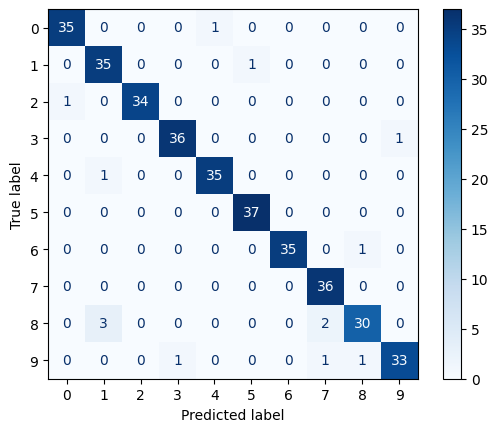

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.90      0.97      0.93        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      0.97      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360



In [59]:
cm = confusion_matrix(y_test, y_pred)  # actual first, predicted second
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap='Blues')
plt.show()

print(classification_report(y_test, y_pred))


#### Time to save the model

In [56]:
joblib.dump(model, 'models/random_forest_model.pkl')

## saving the scores as jsons, dvc can track this for comparing across versions

scores = {
    "accuracy": accuracy,
    "f1_weighted": report['weighted avg']['f1-score'],
    "precision_weighted": report['weighted avg']['precision'],
    "recall_weighted": report['weighted avg']['recall']
}

with open('metrics/scores.json', 'w') as f:
    json.dump(scores, f, indent=4)

print("Model saved to models/random_forest_model.pkl")
print("Metrics saved to metrics/scores.json")    

Model saved to models/random_forest_model.pkl
Metrics saved to metrics/scores.json


## Second Experiment

In [60]:
git_hash = subprocess.check_output(['git', 'rev-parse', 'HEAD']).decode().strip()

n_estimators_v2 = 200
max_depth_v2 = None

with mlflow.start_run(run_name="random-forest-v2"):

    # Link to Git+DVC snapshot
    mlflow.log_param("git_commit", git_hash)
    mlflow.log_param("data_version", git_hash[:8])

    # Log hyperparameters
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("n_estimators", n_estimators_v2)
    mlflow.log_param("max_depth", str(max_depth_v2))
    mlflow.log_param("test_size", 0.2)
    mlflow.log_param("scaler", "StandardScaler")

    # Train
    model_v2 = RandomForestClassifier(
        n_estimators=n_estimators_v2,
        max_depth=max_depth_v2,
        random_state=42
    )
    model_v2.fit(X_train_scaled, y_train)

    # Predict + evaluate
    y_pred_v2 = model_v2.predict(X_test_scaled)
    accuracy_v2 = accuracy_score(y_test, y_pred_v2)
    report_v2 = classification_report(y_test, y_pred_v2, output_dict=True)

    # Log metrics
    mlflow.log_metric("accuracy", accuracy_v2)
    mlflow.log_metric("f1_weighted", report_v2['weighted avg']['f1-score'])
    mlflow.log_metric("precision_weighted", report_v2['weighted avg']['precision'])
    mlflow.log_metric("recall_weighted", report_v2['weighted avg']['recall'])

    # Log model
    mlflow.sklearn.log_model(model_v2, "random_forest_model")

    print(f"V1 accuracy: {accuracy:.4f}")
    print(f"V2 accuracy: {accuracy_v2:.4f}")
    print(f"Improvement: {(accuracy_v2 - accuracy)*100:+.2f}%")
    print(f"Git commit:  {git_hash[:8]}")

2026/05/12 16:56:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 16:56:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


V1 accuracy: 0.9611
V2 accuracy: 0.9639
Improvement: +0.28%
Git commit:  425b7f94
🏃 View run random-forest-v2 at: https://dagshub.com/dbhagria-2004/ML-PIPELINE-TEST.mlflow/#/experiments/0/runs/ad3ec1b227644fdcad294b6e868ec120
🧪 View experiment at: https://dagshub.com/dbhagria-2004/ML-PIPELINE-TEST.mlflow/#/experiments/0
